# Molecular docking on a Coherent Ising Machine

Two protein-ligand complexes -- PDB **1N2J** and **1LRH** -- are redocked on a
real **Coherent Ising Machine** (CIM) through the **Kaiwu SDK**. Each pose search is
written as a **QUBO** with the **Grid Point Matching** encoding and solved on the
photonic hardware in **quota mode at 8-bit precision**.

The real CIM solutions are bundled in `results/`, so every cell reproduces offline --
no license needed. Set `QDOCK_LIVE=1` with your own credentials to resubmit to the
hardware.

## Setup

In [1]:
import os, sys
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)

import sys, numpy as np
from types import SimpleNamespace
from qdock_kaiwu import backends, evaluate
from qdock_kaiwu.gpm import _matches_to_poses

MOLS = ["1N2J", "1LRH"]
B = {p: dict(np.load(f"{ROOT}/results/{p}_cim.npz", allow_pickle=True)) for p in MOLS}
print("loaded bundles:", ", ".join(f"{p} ({int(B[p]['n_runs'])} pooled CIM runs)"
      for p in MOLS))

loaded bundles: 1N2J (10 pooled CIM runs), 1LRH (8 pooled CIM runs)


## 1. The Grid Point Matching QUBO

Grid Point Matching (GPM) lays a regular grid of candidate positions over the binding
box and assigns one binary variable to each *(ligand atom, grid point)* pair:

$$x_{a,s}=1 \iff \text{atom } a \text{ occupies grid point } s.$$

The energy minimised is

```
H(x) = Σ w[a,s]·x[a,s]
     + K_dist · Σ ( ‖d_lig − d_grid‖ > c ) · x_p·x_q      # shape distortion
     + K_mono · Σ ( same atom )            · x_p·x_q      # one atom, one point
```

- **w[a,s]** is the AutoGrid van-der-Waals energy of atom *a* at grid point *s* -- a
  favourable placement is negative, so it is rewarded;
- **K_dist** penalises matches that would stretch the rigid ligand;
- **K_mono** forbids one atom from taking two grid points.

Minimising `H` yields a consistent set of matches; Kabsch-superposing the matched
atoms onto their grid points produces a 3-D pose. Each bundle ships the prebuilt QUBO
`Q` together with the metadata needed to decode a solution back into coordinates.

In [2]:
p = "1N2J"; Q = B[p]["Q"].astype(float)
print(f"{p}: QUBO is {Q.shape[0]}x{Q.shape[0]}  ({B[p]['n_vars']} binary variables)")
print("diagonal (per-match rewards w), first 5:", np.round(np.diag(Q)[:5], 3))

1N2J: QUBO is 232x232  (232 binary variables)
diagonal (per-match rewards w), first 5: [-0.467 -0.288 -0.243 -0.403 -0.354]


## 2. Solving on the CIM with Kaiwu

Kaiwu minimises an **Ising** Hamiltonian and returns **spin** (±1) configurations. The
solve is identical for every molecule:

1. `kw.conversion.qubo_matrix_to_ising_matrix(Q)` rewrites the QUBO as an Ising matrix
   (the converter folds in the sign, so the machine's maximiser minimises our QUBO).
2. `kw.cim.CIMOptimizer(..., task_mode="quota")` submits the matrix to the hardware.
3. `kw.cim.PrecisionReducer(..., precision=8, truncated_precision=8)` runs it at
   **8-bit** precision with **no spin expansion**, so the spin count equals the number
   of variables (232-304 here, well under the 1000-spin budget).
4. `reducer.solve(ising)` returns the spins, gauged back to binary matches.

The next cell is the complete solve. By default it returns the bundled hardware
solutions; with a license and `QDOCK_LIVE=1` it submits a fresh quota job.

In [3]:
import os, tempfile
LIVE = bool(int(os.environ.get("QDOCK_LIVE", "0")))   # 1 + a license -> use the hardware

def cim_solve(Q, task_name, shipped):
    # Solve a QUBO on the CIM in quota mode at 8-bit precision; return binary reads.
    # Offline (default) returns the bundled real-CIM solutions for the same QUBO.
    if not LIVE:
        return shipped
    import kaiwu as kw
    kw.license.init(user_id=os.environ["KAIWU_USER_ID"], sdk_code=os.environ["KAIWU_SDK_CODE"])
    kw.common.CheckpointManager.save_dir = tempfile.mkdtemp()
    ising, offset = kw.conversion.qubo_matrix_to_ising_matrix(Q)        # QUBO -> Ising
    cim = kw.cim.CIMOptimizer(task_name=task_name, wait=True, interval=2,
                              task_mode="quota", sample_number=300)      # quota mode
    reducer = kw.cim.PrecisionReducer(cim, precision=8, truncated_precision=8,
                                      only_feasible_solution=False)      # 8-bit, no expansion
    spins = np.asarray(reducer.solve(ising))                            # submit -> poll -> spins
    return [backends._spins_to_binary(s, Q.shape[0]) for s in spins]    # gauge ±1 -> binary

reads = cim_solve(Q, "qdock_1N2J", list(B["1N2J"]["solutions"]))
print(f"got {len(reads)} solutions over {Q.shape[0]} spins")

got 59 solutions over 232 spins


## 3. From spins to a pose

Every spin row is gauged to a binary match vector, the unique matches are ranked by
QUBO energy, and the matched atoms are Kabsch-superposed onto their grid points. The
**mRMSD** -- the smallest heavy-atom RMSD to the crystal ligand over the pooled poses --
measures the *sampling power*: does a near-native pose exist in the pool?

In [4]:
def decode(d):
    # Decode a bundle's pooled solutions (in stored order) into 3-D poses + RMSDs.
    Q = d["Q"].astype(float)
    ranked = list(zip(d["energies"].tolist(), [s for s in d["solutions"]]))
    lig = SimpleNamespace(coords=d["lig_coords"])
    poses, _ = _matches_to_poses(lig, d["variables"], d["box_coords"], ranked)
    poses = np.array(poses)
    rmsd = evaluate.pose_rmsds(poses, d["lig_coords"], d["lig_elements"])
    return poses, rmsd

poses, rmsd = decode(B["1N2J"])
print(f"1N2J: {len(poses)} unique poses,  mRMSD = {rmsd.min():.2f} Å")

1N2J: 50 unique poses,  mRMSD = 0.41 Å


## 4. The same recipe on all three targets

One fixed recipe -- quota mode, 8-bit, pooled runs -- applied to each complex.

In [5]:
print(f"{'PDB':<6}{'spins':>7}{'grid/Å':>8}{'poses':>7}{'mRMSD/Å':>9}")
for p in MOLS:
    d = B[p]; _, r = decode(d)
    print(f"{p:<6}{int(d['n_vars']):>7}{float(d['grid_length']):>8.1f}"
          f"{len(r):>7}{r.min():>9.2f}")

PDB     spins  grid/Å  poses  mRMSD/Å
1N2J      232     2.0     50     0.41
1LRH      304     2.0     38     0.74


## 5. Reproducibility across independent runs

The CIM is stochastic: each submission is an independent draw, and the near-native
pose surfaces in only a fraction of them, so the recipe pools several runs and keeps
the best. The table reports, per target, how many independent hardware runs reached a
docking-quality pose (< 2 Å) and a near-native pose (< 1 Å).

In [6]:
print(f"{'PDB':<6}{'runs':>6}{'<2Å':>7}{'<1Å':>7}{'best':>7}{'median':>8}")
for p in MOLS:
    r = B[p]["per_run_rmsd"]
    print(f"{p:<6}{len(r):>6}{f'{int((r<2).sum())}/{len(r)}':>7}"
          f"{f'{int((r<1).sum())}/{len(r)}':>7}{r.min():>7.2f}{np.median(r):>8.2f}")

PDB     runs    <2Å    <1Å   best  median
1N2J      10  10/10   4/10   0.41    1.04
1LRH       8    6/8    6/8   0.74    0.78


## 6. Scoring the poses with AutoDock Vina

A low RMSD means a good pose *exists* in the pool (sampling power). Whether a
physics-based scoring function can *select* it is a separate question (scoring power).
Each pooled pose is rescored with `AutoDock Vina --score_only` and the top-1 is the
lowest-affinity pose -- for both targets it is the near-native pose, so sampling and
scoring agree here. (Scores are bundled, so this cell needs no Vina binary.)

In [7]:
print(f"{'PDB':<6}{'Vina top-1':>11}{'top-1 RMSD':>12}{'mRMSD':>8}{'crystal Vina':>14}")
for p in MOLS:
    d = B[p]; _, rmsd = decode(d)
    vina = d["vina_scores"]; i = int(np.nanargmin(vina))
    print(f"{p:<6}{vina[i]:>11.2f}{rmsd[i]:>12.2f}{rmsd.min():>8.2f}"
          f"{float(d['crystal_vina']):>14.2f}")
print("\n(Vina affinity in kcal/mol, lower = better; RMSD in Å to the crystal ligand)")

PDB    Vina top-1  top-1 RMSD   mRMSD  crystal Vina
1N2J        -3.97        0.41    0.41         -4.30
1LRH        -5.63        0.74    0.74         -7.44

(Vina affinity in kcal/mol, lower = better; RMSD in Å to the crystal ligand)


## 7. Best pose vs crystal

The lowest-RMSD CIM pose (coloured sticks) overlaid on the crystal ligand (blue).

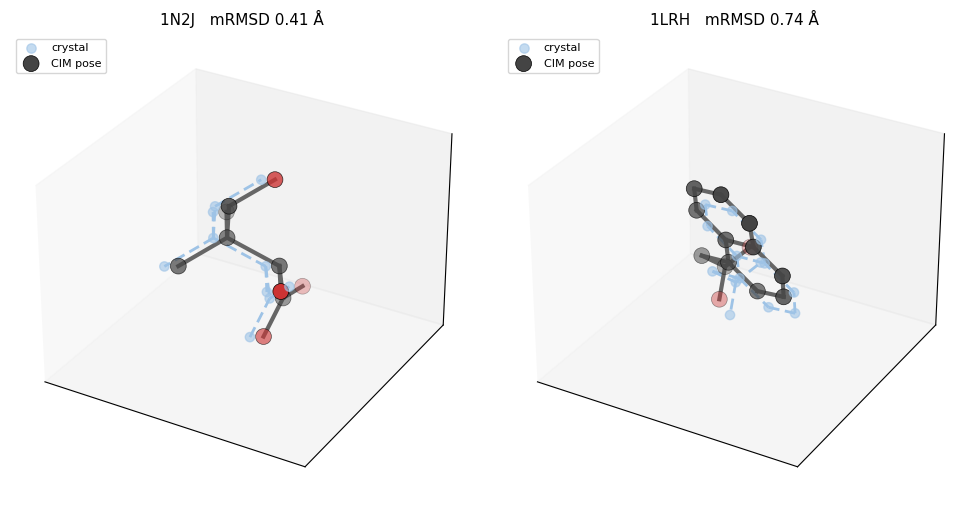

In [8]:
import matplotlib.pyplot as plt

EL = {'C': '#444', 'N': '#2c5fa8', 'O': '#cc3333', 'S': '#d4a000', 'P': '#d4a000',
      'ZN': '#9a6', 'CL': '#3a3'}

def bonds(xyz, el):
    keep = np.array([e != 'H' for e in el]); idx = np.where(keep)[0]; P = xyz[keep]
    return [(idx[i], idx[j]) for i in range(len(P)) for j in range(i + 1, len(P))
            if np.linalg.norm(P[i] - P[j]) < 1.95]

def draw(ax, crystal, docked, el, title):
    el = [str(e).strip().upper() for e in el]
    e1 = [e[:1] for e in el]; keep = [e != 'H' for e in e1]
    for a, b in bonds(crystal, e1): ax.plot(*zip(crystal[a], crystal[b]), color='#9ec3e6', lw=2, ls=(0, (4, 2)))
    for a, b in bonds(docked, e1):  ax.plot(*zip(docked[a], docked[b]), color='#666', lw=3)
    C, Dk = crystal[keep], docked[keep]; ek = [e for e, k in zip(el, keep) if k]
    ax.scatter(*C.T, c='#9ec3e6', s=45, alpha=.6, label='crystal')
    ax.scatter(*Dk.T, c=[EL.get(e, '#888') for e in ek], s=130, edgecolor='k', lw=.5, label='CIM pose')
    P = np.vstack([C, Dk]); c0 = P.mean(0); rad = np.abs(P - c0).max() + 1
    ax.set_xlim(c0[0]-rad, c0[0]+rad); ax.set_ylim(c0[1]-rad, c0[1]+rad); ax.set_zlim(c0[2]-rad, c0[2]+rad)
    ax.set_title(title, fontsize=11); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.legend(fontsize=8, loc='upper left')

fig = plt.figure(figsize=(5 * len(MOLS), 5))
for i, p in enumerate(MOLS):
    d = B[p]; poses, r = decode(d); best = poses[int(r.argmin())]
    draw(fig.add_subplot(1, len(MOLS), i + 1, projection='3d'),
         d["lig_coords"], best, d["lig_elements"], f"{p}   mRMSD {r.min():.2f} Å")
plt.tight_layout()
os.makedirs(os.path.join(ROOT, "assets"), exist_ok=True)
fig.savefig(os.path.join(ROOT, "assets", "docking_demo.png"), dpi=110, bbox_inches="tight")
plt.show()

## 8. Interactive 3-D view

The crystal ligand (cyan) and the best CIM pose (orange) inside the binding pocket --
**drag to rotate, scroll to zoom.** The receptor is a transparent cartoon and the
pocket side-chains are thin sticks. Call `view3d("1LRH")` for the other target, or
`view3d("1N2J", pose=k)` to inspect any pooled pose.

In [9]:
import py3Dmol

def _xyz(elements, coords):
    rows = [str(len(coords)), ""]
    for e, c in zip(elements, coords):
        rows.append(f"{str(e).strip().title():<2} {c[0]:.4f} {c[1]:.4f} {c[2]:.4f}")
    return "\n".join(rows)

def _receptor(pdb):
    return "".join(l[:66] + "\n" for l in open(f"{ROOT}/data/{pdb}_receptor.pdbqt")
                   if l.startswith(("ATOM", "HETATM")))

def view3d(pdb, pose=None, width=760, height=520):
    d = B[pdb]; poses, rmsd = decode(d)
    k = int(rmsd.argmin()) if pose is None else int(pose)
    v = py3Dmol.view(width=width, height=height)
    v.addModel(_receptor(pdb), "pdb")                              # model 0: protein
    v.addModel(_xyz(d["lig_elements"], d["lig_coords"]), "xyz")    # model 1: crystal pose
    v.addModel(_xyz(d["lig_elements"], poses[k]), "xyz")          # model 2: CIM pose
    v.setStyle({"model": 0}, {"cartoon": {"color": "spectrum", "opacity": 0.55}})
    v.addStyle({"model": 0, "within": {"distance": 4.5, "sel": {"model": 1}}},
               {"stick": {"colorscheme": "whiteCarbon", "radius": 0.1}})   # pocket side-chains
    v.setStyle({"model": 1}, {"stick": {"colorscheme": "cyanCarbon", "radius": 0.16}})
    v.setStyle({"model": 2}, {"stick": {"colorscheme": "orangeCarbon", "radius": 0.2},
                              "sphere": {"scale": 0.25}})
    v.zoomTo({"model": 1}); v.zoom(0.6); v.setBackgroundColor("white")
    v.show()

view3d("1N2J")   # try view3d("1LRH") or view3d("1N2J", pose=3)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## The classical solver

The identical QUBO also runs on Kaiwu's CPU simulated-annealing optimiser,
`kw.classical.SimulatedAnnealingOptimizer(...)` (wrapped in `backends.solve_sa`) --
useful for developing the encoding before spending CIM quota.

## References

- Wei *et al.*, "A versatile coherent Ising computing platform," *Light: Science &
  Applications* (2026) 15:74. DOI 10.1038/s41377-025-02178-1.
- Zha *et al.*, "Encoding Molecular Docking for Quantum Computers," *JCTC* (2024).
  DOI 10.1021/acs.jctc.3c00943.